# GenCare AI finetuning
---
Auteur:   Eva Rombouts  
Datum:    26-12-2023.  
Doel:     Ervaring opdoen met Python, NLP  
Doel project: Voorspellen onrustscores met een llm  

Voor dit script wordt gebruik gemaakt van data gegenereerd met de OpenAI API.  

---

## Setup

In [1]:
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Parameters
seed = 6
max_len = 512  # Max lengte van een tekst voor BERT
batch_size = 16
learning_rate = 2e-5
epochs = 3

## Model
De taak die we willen gaan ondernemen: Onrustscores voorspellen op basis van teksten. 
Dit is in essentie een vorm van regressie, met het doel om een continue waarde te voorspellen. Hiervoor moet een transformermodel eerst worden aangepast voor regressie. 

Modelkeuze: Mogelijkheden zijn BERT, RoBERTa, of DistilBERT. Deze modellen zijn al getraind op grote tekstcorpora en hebben een goed begrip van taalstructuren.

Om te beginnen start ik met BERT. Om een idee te krijgen van de structuur van het model is het van belang om de architectuur te bestuderen. Dat gebeurt hieronder. 

In [3]:
model_naam = 'wietsedv/bert-base-dutch-cased'
tokenizer = BertTokenizer.from_pretrained(model_naam)
model = BertModel.from_pretrained(model_naam)

model

Some weights of BertModel were not initialized from the model checkpoint at wietsedv/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30073, 768, padding_idx=3)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Beschrijving BERT architectuur
(Uitleg aangepast van ChatGPT)

Deze architectuur is van het model BertForSequenceClassification, een variant van BERT (Bidirectional Encoder Representations from Transformers) die specifiek is ontworpen voor sequentieclassificatietaken. Hier zijn de belangrijkste eigenschappen:

**BERT Model**: Het is een transformer-model dat gebruikmaakt van de transformer-architectuur, vooral bekend om zijn vermogen om contextuele relaties tussen woorden in een tekst te begrijpen. BERT is pre-trained op een grote hoeveelheid tekst en kan worden aangepast aan specifieke taken (zoals classificatie).

**Embeddings**:
- Woordembeddings: Deze vertegenwoordigen individuele woorden in een dichte vectorruimte. De dimensie van deze embeddings is 768.
- Positie-embeddings: BERT neemt volgorde-informatie op door gebruik te maken van positie-embeddings. Deze zijn ook van dimensie 768.
- Token Type Embeddings: Worden gebruikt voor het onderscheiden van verschillende zinnen of taken in een input.
- Layer Normalization en Dropout: Deze worden gebruikt voor normalisatie en om overfitting te voorkomen.

**BertEncoder**: Het hart van het model, bestaande uit 12 transformer-lagen (voor de basisvariant van BERT). Elke laag heeft:
- BertAttention: Een mechanisme dat de modelinvoer 'bekijkt' en bepaalt welke delen van de invoer belangrijk zijn.
- BertIntermediate: Een feedforward netwerk dat de dimensie tijdelijk verhoogt van 768 naar 3072 voor meer complexe representaties.
- BertOutput: Converteert de dimensie terug van 3072 naar 768 en past nog een laagnormalisatie en dropout toe.

**BertPooler**: Een laag die de output van de laatste encoder-laag transformeert en zorgt voor een vaste outputgrootte, wat belangrijk is voor classificatiedoeleinden.

Deze architectuur is krachtig voor sequentieclassificatie vanwege zijn vermogen om rijke, contextuele representaties van tekst te genereren, waardoor het model subtiele nuances en complexe patronen in tekstgegevens kan begrijpen en classificeren.

### Aanpassen voor Regressie
Hoewel deze modellen doorgaans worden gebruikt voor classificatie of andere NLP-taken, kunnen ze worden aangepast voor regressie. Dit houdt in dat als laatste laag een regressielaag wordt toegevoegd (een lineaire laag die één output produceert).

In [4]:
# Definitie van klasse. Deze erft van nn.Module - een basisklasse voor alle neurale netwerk modules in PyTorch
class BertForRegression(nn.Module):
    # __init__ is een speciale methode die wordt aangeroepen als een nieuwe instantie (object) van een klasse wordt gemaakt. Hierbij moet dus een bert_model als parameter worden meegegeven
    def __init__(self, bert_model):
        # Roep de constructor (= __init__) van de bovenliggende klasse aan
        super(BertForRegression, self).__init__()
        # Wijs het model toe aan self.bert
        self.bert = bert_model
        # De regressielaag: BERT's outputgrootte (768 voor base-modellen) naar 1
        self.regression = nn.Linear(768, 1)

    def forward(self, input_ids, attention_mask):
        # De output van BERT
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Neem de output van de laatste verborgen laag voor de [CLS] token
        cls_output = outputs.last_hidden_state[:, 0, :]
        # Pas de regressielaag toe
        return self.regression(cls_output)

# Maak een instantie van het aangepaste model
regression_model = BertForRegression(model)

## Data voorbereiding
Onderstaande code is bedoeld voor data voorbereiding en het creëren van Datasets en DataLoaders voor een natuurlijke taalverwerkingstaak. We maken gebruik van pandas, scikit-learn en PyTorch.

### Inlezen 

In [5]:
gci = pd.read_csv('../zorgdata/df_rapportages.csv')

In [6]:
gci.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   afdeling     6341 non-null   object 
 1   client_id    6341 non-null   object 
 2   weekno       6341 non-null   int64  
 3   dag          6341 non-null   object 
 4   niveau       6341 non-null   object 
 5   rapportage   6341 non-null   object 
 6   onrustscore  6334 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 346.9+ KB


### Opschonen

In [7]:
# Er zijn 7 rijen zonder onrustscore. Verwijder:
gci.dropna(inplace=True)
gci.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6334 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   afdeling     6334 non-null   object 
 1   client_id    6334 non-null   object 
 2   weekno       6334 non-null   int64  
 3   dag          6334 non-null   object 
 4   niveau       6334 non-null   object 
 5   rapportage   6334 non-null   object 
 6   onrustscore  6334 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 395.9+ KB


### Split train/test/validatie

In [8]:
# Eerste split: 80% train, 20% tijdelijk (val+test)
df_train, df_temp = train_test_split(gci, test_size=0.2, random_state=seed)
# Tweede split: split de 20% tijdelijk in 10% val, 10% test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=seed)

print(f'Trainset: {len(df_train)}')
print(f'Validatieset: {len(df_val)}')
print(f'Testset: {len(df_test)}')

Trainset: 5067
Validatieset: 633
Testset: 634


### Dataset Class Definitie
Een Python class RapportageDataset wordt gedefinieerd, afgeleid van Dataset. Deze class is ontworpen om met tekstgegevens te werken. Voor elk item in de dataset, wordt de tekst getokeniseerd en de bijbehorende score voor onrust wordt ook opgenomen.

In [9]:
class RapportageDataset(Dataset):
    def __init__(self, teksten, scores, tokenizer, max_len):
        self.teksten = teksten
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.teksten)

    def __getitem__(self, item):
        tekst = str(self.teksten[item])
        score = self.scores[item]

        encoding = self.tokenizer.encode_plus(
            tekst,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': tekst,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'score': torch.tensor(score, dtype=torch.float)
        }

Vervolgens worden verschillende Dataloaders gecreeerd. Dit zijn iterators die batches van data genereren.

In [10]:
# Datasets voorbereiden
train_data = RapportageDataset(
    teksten=df_train['rapportage'].to_numpy(),
    scores=df_train['onrustscore'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)

val_data = RapportageDataset(
    teksten=df_val['rapportage'].to_numpy(),
    scores=df_val['onrustscore'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)

test_data = RapportageDataset(
    teksten=df_test['rapportage'].to_numpy(),
    scores=df_test['onrustscore'].to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
)

# Dataloaders voorbereiden
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

Ter illustratie

In [29]:
# Haal de eerste batch op
first_batch = next(iter(train_loader))

# Uitpakken van de inhoud van de batch
teksten = first_batch['text']
input_ids = first_batch['input_ids']
attention_masks = first_batch['attention_mask']
scores = first_batch['score']

print("Teksten:", teksten)
print("Input IDs:", input_ids)
print("Attention Masks:", attention_masks)
print("Scores:", scores)
print(len(scores))


Teksten: ['Vanochtend heb ik Mevrouw Berkhof geholpen met het wassen en aankleden. Ze had wat moeite met bewegen vanwege de stijfheid in haar ledematen, maar met wat extra ondersteuning is het gelukt. Tijdens het ontbijt was ze rustig en genoot ze van haar boterham. Na het ontbijt heb ik haar begeleid naar de activiteitenruimte, waar ze heeft deelgenomen aan een schilderactiviteit. Ze leek zich erg te vermaken. Geen tekenen van onrust vandaag.', 'Vanochtend was meneer Prins wat onrustiger dan normaal. Hij was verward en had moeite om zijn koffie te herkennen. Ik heb hem geholpen door de beker voor hem neer te zetten en hem stap voor stap te begeleiden bij het drinken. Dit leek hem te helpen kalmeren. Later op de ochtend merkte ik dat hij wat onrustig werd tijdens een groepsactiviteit. Ik heb hem naar een rustige plek gebracht en rustgevende muziek opgezet om hem te helpen ontspannen. In de avond had hij moeite om in slaap te vallen. Ik heb hem gerustgesteld en een warme drank gegeven, 

Training: U moet het model trainen met uw specifieke dataset. Dit betekent het voeden van de teksten aan het model en het laten leren van de overeenkomstige onrustscores. Dit proces omvat het definiëren van een geschikte loss-functie voor regressie, zoals Mean Squared Error (MSE) of Mean Absolute Error (MAE).

In [11]:
# Setup van het model en optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
regression_model.to(device)
optimizer = AdamW(regression_model.parameters(), lr=learning_rate)

# Loss functie
loss_fn = nn.MSELoss()

In [12]:
# # Trainingsloop
# for epoch in range(epochs):
#     regression_model.train()
#     loop = tqdm(train_loader, leave=True)
#     for batch in loop:
#         optimizer.zero_grad()
#         input_ids = batch['input_ids'].to(device)
#         attention_mask = batch['attention_mask'].to(device)
#         scores = batch['score'].to(device)

#         outputs = regression_model(input_ids=input_ids, attention_mask=attention_mask)
#         loss = loss_fn(outputs, scores.unsqueeze(1))
        
#         loss.backward()
#         optimizer.step()

#         loop.set_description(f'Epoch {epoch}')
#         loop.set_postfix(loss=loss.item())


In [13]:
# # Opslaan van de modelparameters (aanbevolen methode)
# torch.save(regression_model.state_dict(), '../zorgdata/bert_regression_model.pth')

regression_model.load_state_dict(torch.load('../zorgdata/bert_regression_model.pth'))
regression_model.eval()

BertForRegression(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30073, 768, padding_idx=3)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise


Evaluatie: Beoordeel de prestaties van uw model met behulp van geschikte regressiemetrieken, zoals MSE, MAE, of R-squared.

Fijnafstelling en Optimalisatie: Mogelijk moet u het model finetunen en de hyperparameters optimaliseren om de beste prestaties voor uw specifieke toepassing te bereiken.

Gebruik van een Domeinspecifiek Model: Als er modellen beschikbaar zijn die specifiek zijn getraind op medische of zorggerelateerde gegevens, kunnen deze modellen beter presteren vanwege hun domeinspecifieke kennis.

Een concrete implementatie zou kunnen beginnen met een model als bert-base-uncased (of een Nederlandstalige variant indien uw teksten in het Nederlands zijn), waarbij u vervolgens een regressielaag toevoegt en het model traint met uw dataset van zorgrapportages en bijbehorende onrustscores.

Let's go...  
Stap 1  

Voor het voorspellen van een onrustscore, die in essentie een vorm van regressie is (waarbij het doel is om een continue waarde te voorspellen), zou u een getransformeerd taalmodel kunnen gebruiken dat is aangepast voor regressietaken. Hier zijn een paar stappen en overwegingen:

Modelkeuze: Begin met een voorgeleerd taalmodel zoals BERT, RoBERTa, of DistilBERT. Deze modellen zijn al getraind op grote tekstcorpora en hebben een goed begrip van taalstructuren.


In [14]:
def evaluate_model(model, data_loader, device):
    # Zorg ervoor dat het model in evaluatiemodus staat
    model.eval()

    # List om de voorspellingen op te slaan
    predictions = []
    actual_scores = []

    with torch.no_grad():
        for batch in data_loader:
            # Haal de input_ids en scores uit de batch
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            scores = batch['score'].to(device)

            # Doe de voorspelling
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions.extend(outputs.flatten().cpu().numpy())
            actual_scores.extend(scores.flatten().cpu().numpy())

    mse = mean_squared_error(actual_scores, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_scores, predictions)

    return mse, rmse, mae

Met 6000 rapportages:  
MSE: 592.2482299804688  
RMSE: 24.336151123046875  
MAE: 18.430513381958008

In [ ]:
# Draai de functie. Duurt ruim 2 minuten
mse, rmse, mae = evaluate_model(regression_model, test_loader, device)

print(f'Mean Squared Error: {mse}')
print(f'RMSE: {rmse}')
print(f'Mean Absolute Error: {mae}')

In [28]:
# Zorg ervoor dat het model in evaluatiemodus staat
regression_model.eval()

# List om de voorspellingen op te slaan
predictions = []
actual_scores = []

with torch.no_grad():
    for batch in test_loader:
        # Haal de input_ids en scores uit de batch
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        scores = batch['score'].to(device)

        # Doe de voorspelling
        outputs = regression_model(input_ids=input_ids, attention_mask=attention_mask)
        predictions.extend(outputs.flatten().cpu().numpy())
        actual_scores.extend(scores.flatten().cpu().numpy())

mse = mean_squared_error(actual_scores, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_scores, predictions)


Maar een plotje zegt meer...

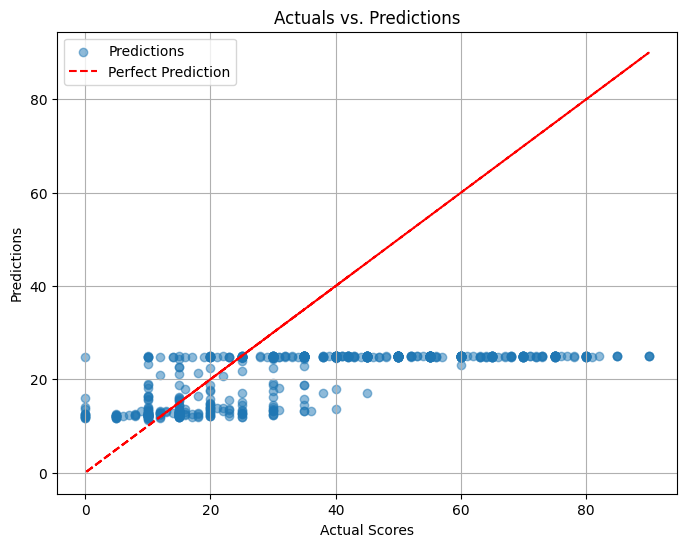

In [34]:
import matplotlib.pyplot as plt

# Plot de actuals vs. voorspellingen
plt.figure(figsize=(8, 6))
plt.scatter(actual_scores, predictions, alpha=0.5)
plt.xlabel('Actual Scores')
plt.ylabel('Predictions')
plt.title('Actuals vs. Predictions')
plt.grid(True)

# Voeg een lijn toe voor perfecte voorspelling (y = x)
plt.plot(actual_scores, actual_scores, color='red', linestyle='--')
plt.legend(['Predictions', 'Perfect Prediction'])
plt.show()


In [40]:
print(np.mean(predictions))
print(np.max(predictions))
print(np.median(predictions))
print(np.mean(actual_scores))
print(np.median(actual_scores))

21.114653
24.93408
24.890652
37.211357
35.0
